In [1]:
import pandas as pd
import os
import librosa as librs
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt
import os
import wave
import matplotlib.pylab as pyl
import soundfile as sf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, Activation, BatchNormalization, SpatialDropout1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [4]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

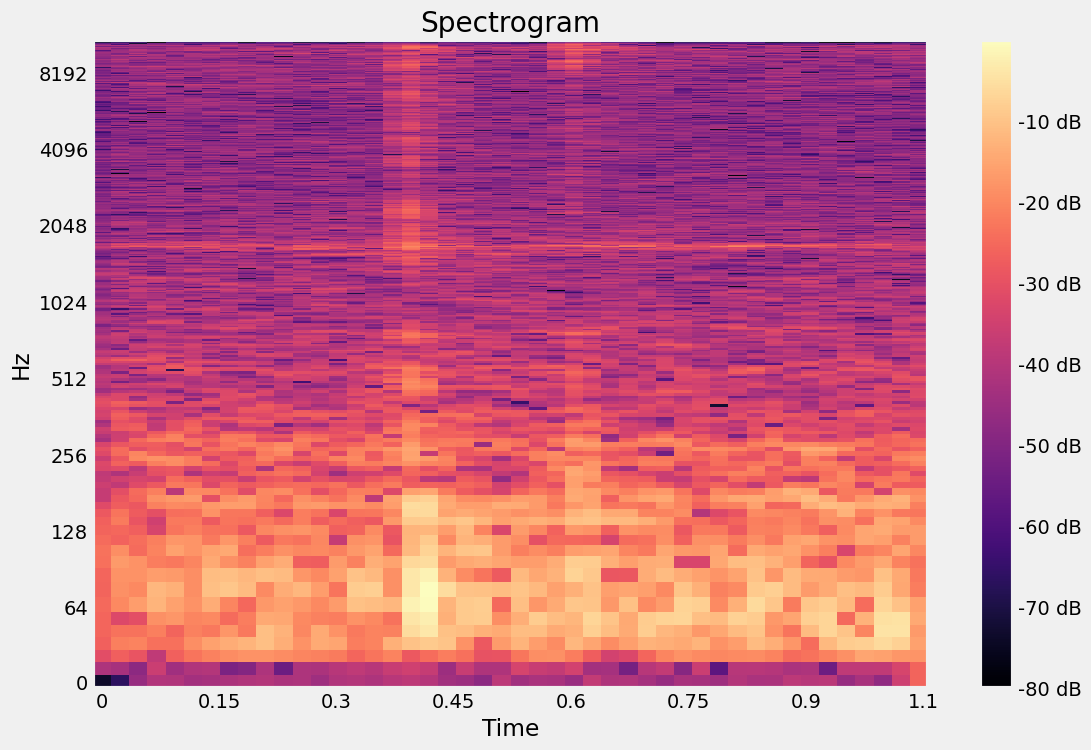

sr:  22050


In [80]:
# Load the audio file
input_wav = "./archive/fold16/output/augmented_A_split_15_2.wav"
y, sr = librs.load(input_wav)

# Compute the spectrogram
D = librs.amplitude_to_db(np.abs(librs.stft(y)), ref=np.max)

# Plot the spectrogram
plt.figure(figsize=(12, 8))
librs.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.savefig('results/spectrogram.png')
plt.show()

print('sr: ',sr)

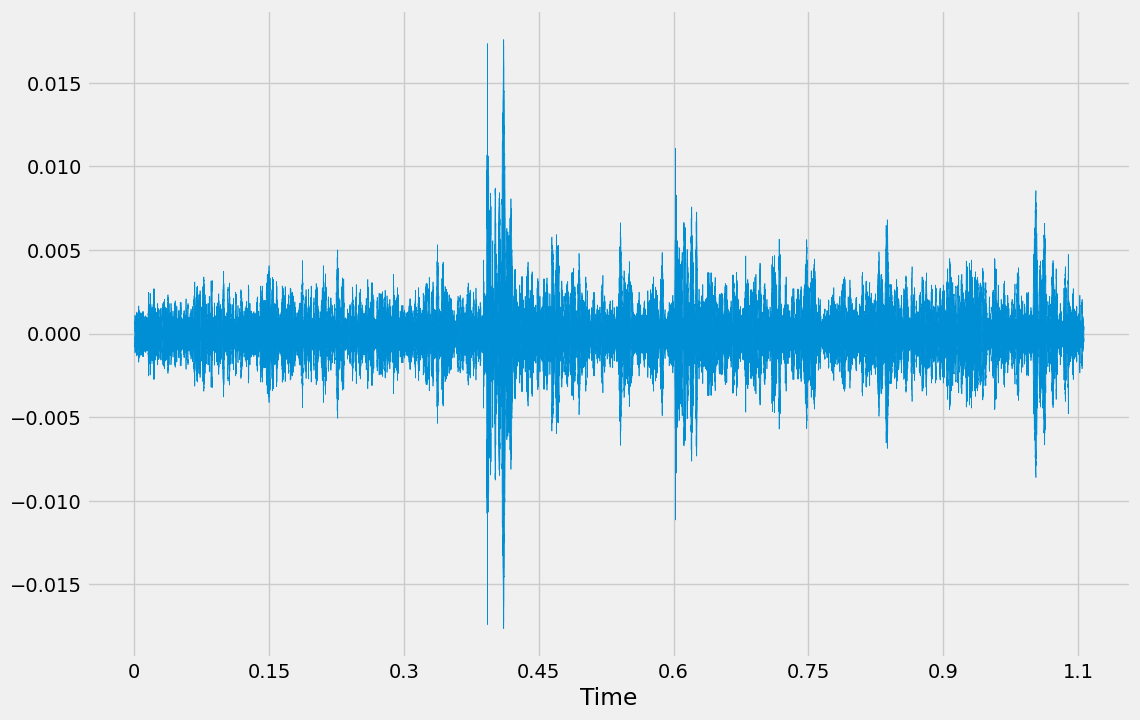

In [81]:
file_name='./archive/fold16/output/augmented_A_split_15_2.wav'
audio_data, sampling_rate = librs.load(file_name)
plt.figure(figsize=(12, 8))
librs.display.waveshow(audio_data,sr=sampling_rate)
plt.savefig("results/wave.png")
ipd.Audio(file_name)

In [7]:
print(audio_data)

[-3.0517578e-05  9.1552734e-05 -3.0517578e-05 ... -6.1035156e-04
 -6.1035156e-05  5.1879883e-04]


In [8]:
audio_dataset_path='./archive/'
metadata = pd.read_csv('./archive/list.csv')
metadata.head()

,slice_file_name,fold,classID,class
0,augmented_0_split_10_0.wav,16,1,0
1,augmented_0_split_10_1.wav,16,1,0
2,augmented_0_split_10_2.wav,16,1,0
3,augmented_0_split_11_0.wav,16,1,0
4,augmented_0_split_11_1.wav,16,1,0


In [9]:
metadata['class'].value_counts()

class
0    75
1    75
K    75
L    75
M    75
N    75
O    75
P    75
Q    75
R    75
S    75
T    75
U    75
V    75
W    75
X    75
Y    75
J    75
I    75
H    75
8    75
2    75
3    75
4    75
5    75
6    75
7    75
9    75
G    75
A    75
B    75
C    75
D    75
E    75
F    75
Z    75
Name: count, dtype: int64

In [10]:
mfccs = librs.feature.mfcc(y = audio_data, sr = 22050, n_mfcc = 36)

In [11]:
mfccs

array([[-7.0557635e+02, -6.2953052e+02, -5.8197736e+02, ...,
        -5.1024493e+02, -5.0885684e+02, -5.2585699e+02],
       [ 3.1580372e+01,  4.5733871e+01,  5.5592247e+01, ...,
         6.1082764e+01,  6.1266586e+01,  5.6445389e+01],
       [ 2.7277256e+01,  3.2801720e+01,  3.6809357e+01, ...,
         4.1284458e+01,  3.9370316e+01,  3.8150276e+01],
       ...,
       [-2.8463376e+00, -2.4725764e+00, -2.9208050e+00, ...,
         2.5894335e-01, -2.7213454e+00, -4.0089369e+00],
       [ 5.3262100e+00, -4.8045759e+00, -9.4348812e+00, ...,
        -2.3760285e+00, -1.5781291e+00, -3.9439025e+00],
       [ 4.0674639e+00, -4.8066926e-01, -5.1941919e+00, ...,
         3.3453827e+00,  2.7604437e+00, -1.5472934e+00]], dtype=float32)

In [12]:
def features_extractor(file):
    audio, sample_rate = librs.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)

    return mfccs_scaled_features

In [13]:
extracted_features=[]
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'\\','output',str(row["slice_file_name"]))
    #print(file_name)
    final_class_labels = row["class"]
    data = features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

2700it [01:11, 37.90it/s]


In [14]:
extracted_features_df = pd.DataFrame(extracted_features,columns=['feature','class'])
extracted_features_df.head(100)

,feature,class
0,"[-515.1352, 49.142826, 34.872814, 14.654232, 1...",0
1,"[-514.447, 48.727367, 34.6217, 14.812406, 18.5...",0
2,"[-516.18884, 49.696484, 35.011036, 14.6423235,...",0
3,"[-518.14166, 47.129578, 34.439487, 17.159151, ...",0
4,"[-519.348, 47.699993, 34.479202, 16.895504, 20...",0
...,...,...
95,"[-510.77463, 53.860836, 39.635685, 21.09354, 2...",1
96,"[-511.89874, 52.718464, 41.593605, 22.007156, ...",1
97,"[-513.85175, 53.673004, 41.952454, 21.791, 26....",1
98,"[-513.91895, 53.696922, 41.943657, 21.788403, ...",1


In [15]:
X = np.array(extracted_features_df['feature'].tolist())
y = np.array(extracted_features_df['class'].tolist())

In [16]:
labelencoder = LabelEncoder()
y = to_categorical(labelencoder.fit_transform(y))

In [17]:
# Define dataset variables for split in train and test
test_size=0.2
shuffle=True
stratify=None
random_state=3
# Define input shape and number of classes
input_dim = 1
input_shape = (input_dim,)
num_classes = 36
kernel_size = 3
num_filters = 128
num_layers = 4
dropout_rate = 0.2
# Define a custom learning rate
learning_rate = 0.001
# Train the model
batch_size = 32
epochs = 500

In [18]:
#X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, shuffle=shuffle, stratify=stratify)

In [19]:
import tensorflow as tf
print(tf.__version__)

2.12.0


In [20]:
num_labels = y.shape[1]
num_labels

36

In [21]:
def build_tcn(input_shape, num_classes, num_filters=num_filters, kernel_size=kernel_size, num_layers=num_layers, dropout_rate=0.2):
    inputs = Input(shape=input_shape)

    # Expand dimensions to match 3D convolutional input
    x = tf.expand_dims(inputs, axis=-1)

    for i in range(num_layers):
        dilation_rate = 2 ** i
        x = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = SpatialDropout1D(rate=dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [22]:
# Build TCN model
tcn_model = build_tcn(input_shape, num_classes)

In [23]:
# Define an optimizer with the desired learning rate
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model
tcn_model.compile(optimizer=my_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
# Print model summary
tcn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 tf.expand_dims (TFOpLambda)  (None, 1, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 1, 128)            512       
                                                                 
 batch_normalization (BatchN  (None, 1, 128)           512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 1, 128)            0         
                                                                 
 spatial_dropout1d (SpatialD  (None, 1, 128)           0         
 ropout1D)                                                   

In [25]:
from tensorflow.keras.utils import plot_model

# Plot the TCN model and save it as an image file
plot_model(tcn_model, to_file='results/tcn_model.png', show_shapes=True, show_layer_names=True)
print("TCN model architecture saved as 'tcn_model.png'")

TCN model architecture saved as 'tcn_model.png'


In [26]:
with tf.device('/GPU:0'):
    # Code to run on GPU
    # Train the model with augmented data
    history = tcn_model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))    

Epoch 1/500
68/68 [==============================] - 8s 54ms/step - loss: 3.6567 - accuracy: 0.0259 - val_loss: 3.6687 - val_accuracy: 0.0259
Epoch 2/500
68/68 [==============================] - 3s 44ms/step - loss: 3.6211 - accuracy: 0.0292 - val_loss: 3.6430 - val_accuracy: 0.0241
Epoch 3/500
68/68 [==============================] - 3s 45ms/step - loss: 3.6050 - accuracy: 0.0278 - val_loss: 3.6134 - val_accuracy: 0.0241
Epoch 4/500
68/68 [==============================] - 3s 43ms/step - loss: 3.6007 - accuracy: 0.0292 - val_loss: 3.5910 - val_accuracy: 0.0333
Epoch 5/500
68/68 [==============================] - 3s 44ms/step - loss: 3.5706 - accuracy: 0.0319 - val_loss: 3.5431 - val_accuracy: 0.0685
Epoch 6/500
68/68 [==============================] - 3s 39ms/step - loss: 3.5042 - accuracy: 0.0537 - val_loss: 3.3653 - val_accuracy: 0.1185
Epoch 7/500
68/68 [==============================] - 3s 40ms/step - loss: 3.3117 - accuracy: 0.0870 - val_loss: 3.4069 - val_accuracy: 0.0593
Epoch 

In [27]:
# Evaluate the model on the training set
train_loss, train_accuracy = tcn_model.evaluate(X_train, y_train)
print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy*100:.4f}%")

68/68 [==============================] - 1s 14ms/step - loss: 0.0017 - accuracy: 1.0000
Train Loss: 0.0017, Train Accuracy: 100.0000%


In [28]:
# Evaluate the model
test_loss, test_accuracy = tcn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy*100:.4f}%")

17/17 [==============================] - 0s 14ms/step - loss: 0.0713 - accuracy: 0.9889
Test Loss: 0.0713, Test Accuracy: 98.8889%


In [29]:
predictions = tcn_model.predict(X_test)

17/17 [==============================] - 1s 13ms/step


In [30]:
# Get predictions for samples 0 to lenght of X_test
#start_index = 0
start_index = 20
#end_index = len(X_test)
end_index = 56
predictions = tcn_model.predict(X_test[start_index:end_index])
true_labels = np.argmax(y_test[start_index:end_index], axis=1)  # Assuming y_test is one-hot encoded
predicted_labels = np.argmax(predictions, axis=1)

2/2 [==============================] - 0s 7ms/step


In [31]:
my_test_accuracy = accuracy_score(true_labels, predicted_labels)
print("Test Accuracy:", my_test_accuracy*100, "%")

Test Accuracy: 100.0 %


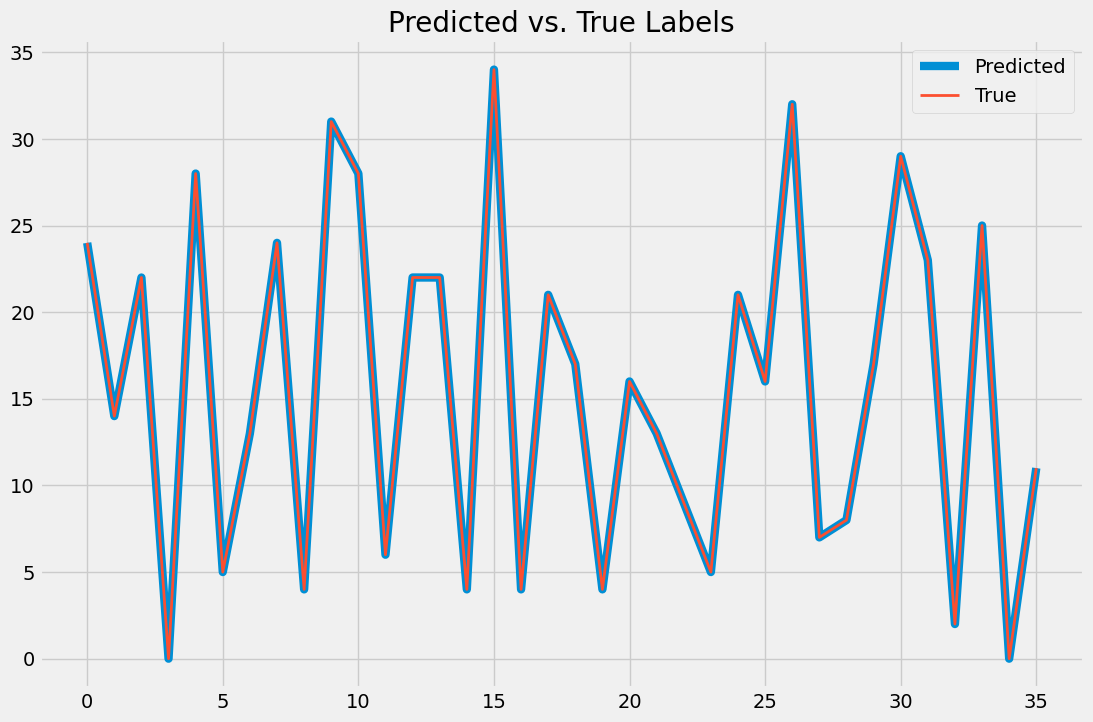

In [32]:
# Create a bar plot to visualize predicted vs. true labels
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))
plt.plot(predicted_labels, label='Predicted', linewidth = '6.0')
plt.plot(true_labels, label='True', linewidth = '2.0')
plt.title('Predicted vs. True Labels')
plt.legend()
plt.savefig('results/inference_curve.png')
plt.show()

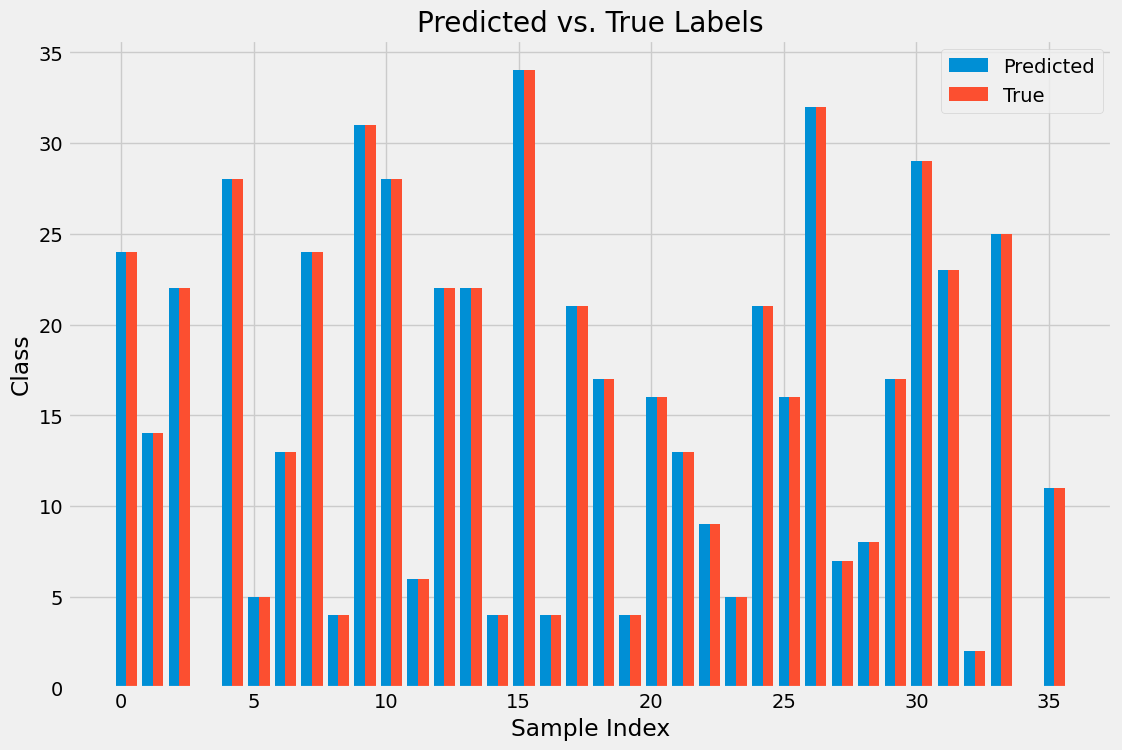

In [33]:
# Create a bar plot to visualize predicted vs. true labels
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))
plt.bar(np.arange(len(predicted_labels)), predicted_labels, width=0.4, label='Predicted', align='center')
plt.bar(np.arange(len(true_labels)) + 0.4, true_labels, width=0.4, label='True', align='center')
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Predicted vs. True Labels')
plt.legend()
plt.savefig('results/inference_bar.png')
plt.show()

In [34]:
def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, title=None, cmap=plt.cm.Blues):
    if not title:
        if normalize:
            title = 'Normalized Confusion Matrix'
        else:
            title = 'Confusion Matrix'

    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


17/17 [==============================] - 0s 11ms/step


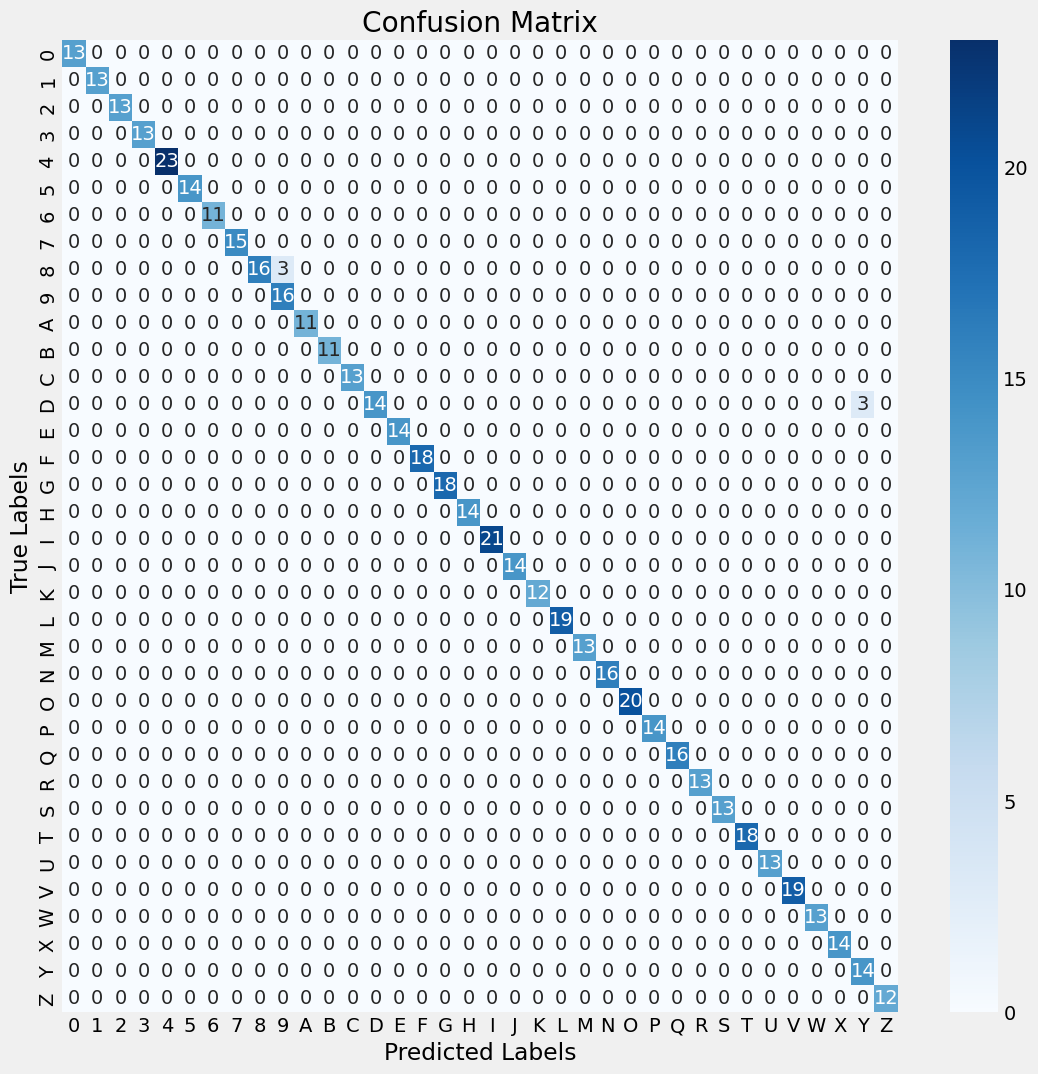

In [35]:
# Make predictions using the model
predictions = tcn_model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
# Replace 'classes' with your actual class labels
#classes = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36']
classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

# Plot the confusion matrix
plt.style.use("fivethirtyeight")
y_true = true_labels
y_pred = predicted_labels
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('results/confusion_matrix.png')
plt.show()

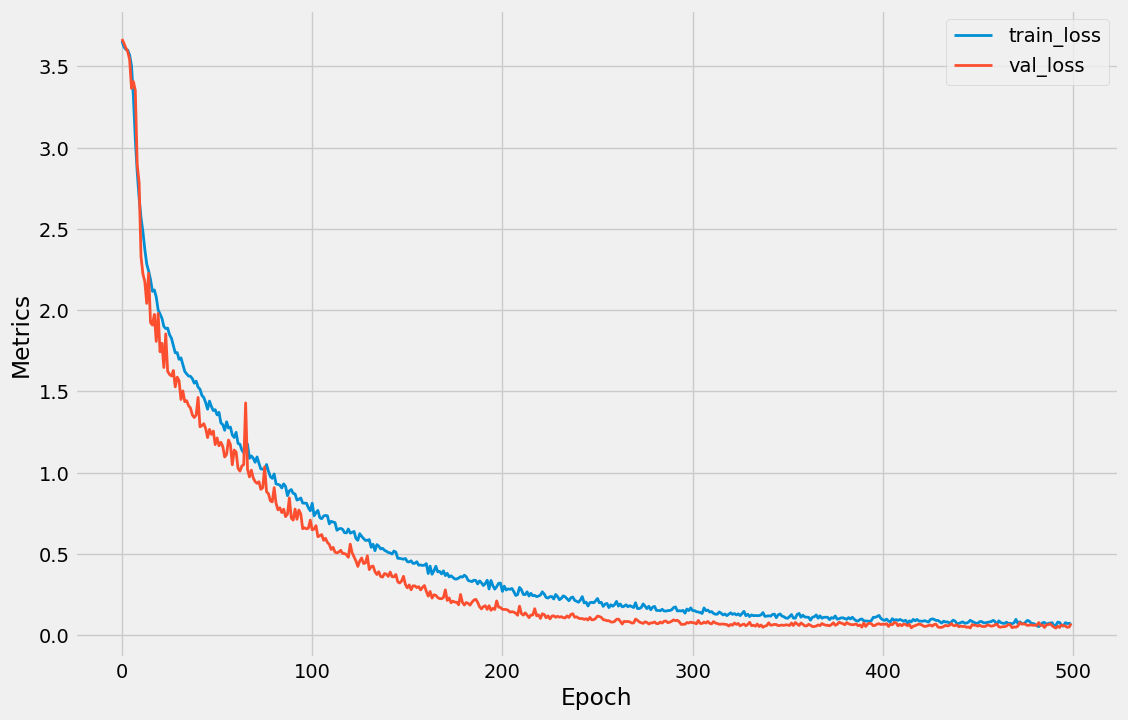

In [36]:
# Plot training history
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.plot(history.history['loss'], label='train_loss', linewidth = '2.0')
plt.plot(history.history['val_loss'], label='val_loss', linewidth = '2.0')
plt.legend(loc = 'best', fontsize=14)
plt.savefig('results/loss.png')
plt.show()

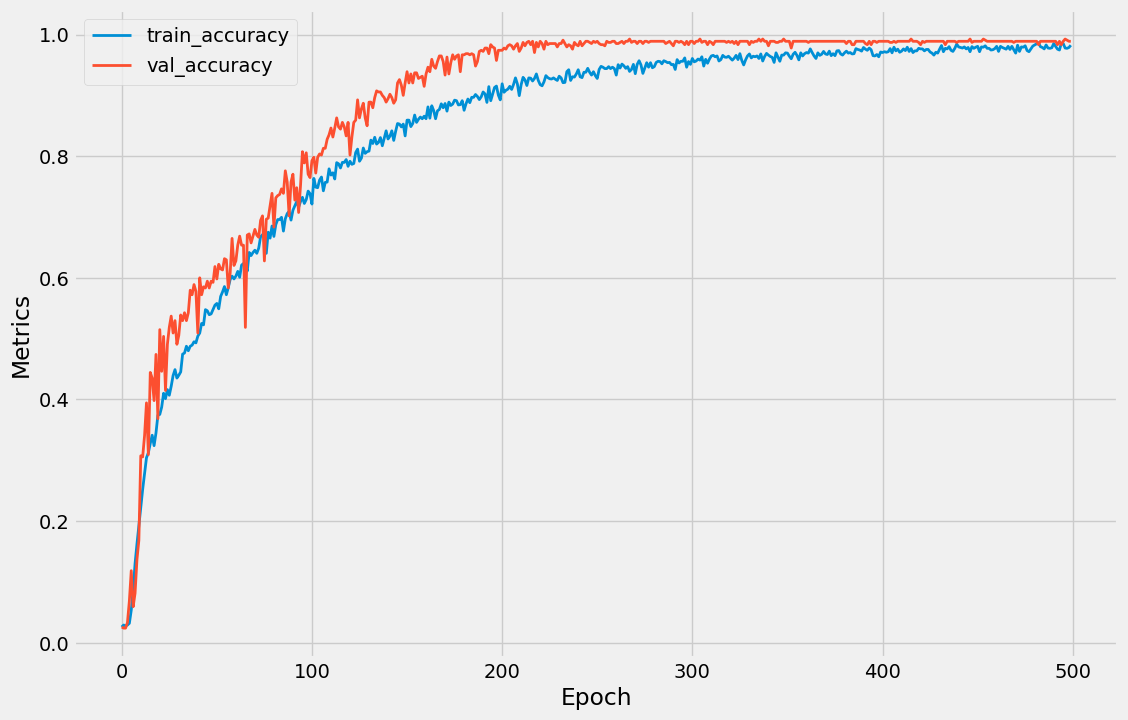

In [37]:
# Plot training history
plt.figure(figsize=(12, 8))
plt.plot(history.history['accuracy'], label='train_accuracy', linewidth = '2.0')
plt.plot(history.history['val_accuracy'], label='val_accuracy', linewidth = '2.0')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.savefig('results/accuracy.png')
plt.show()

In [38]:
# Make predictions using the model
predictions = tcn_model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Calculate and print classification report
report = classification_report(true_labels, predicted_labels, target_names=classes)
print("Classification Report:")
print(report)

17/17 [==============================] - 0s 15ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        23
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        11
           7       1.00      1.00      1.00        15
           8       1.00      0.84      0.91        19
           9       0.84      1.00      0.91        16
           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        11
           C       1.00      1.00      1.00        13
           D       1.00      0.82      0.90        17
           E       1.00      1.00      1.00        14
           F       1.00      1.00      1.00        18
    

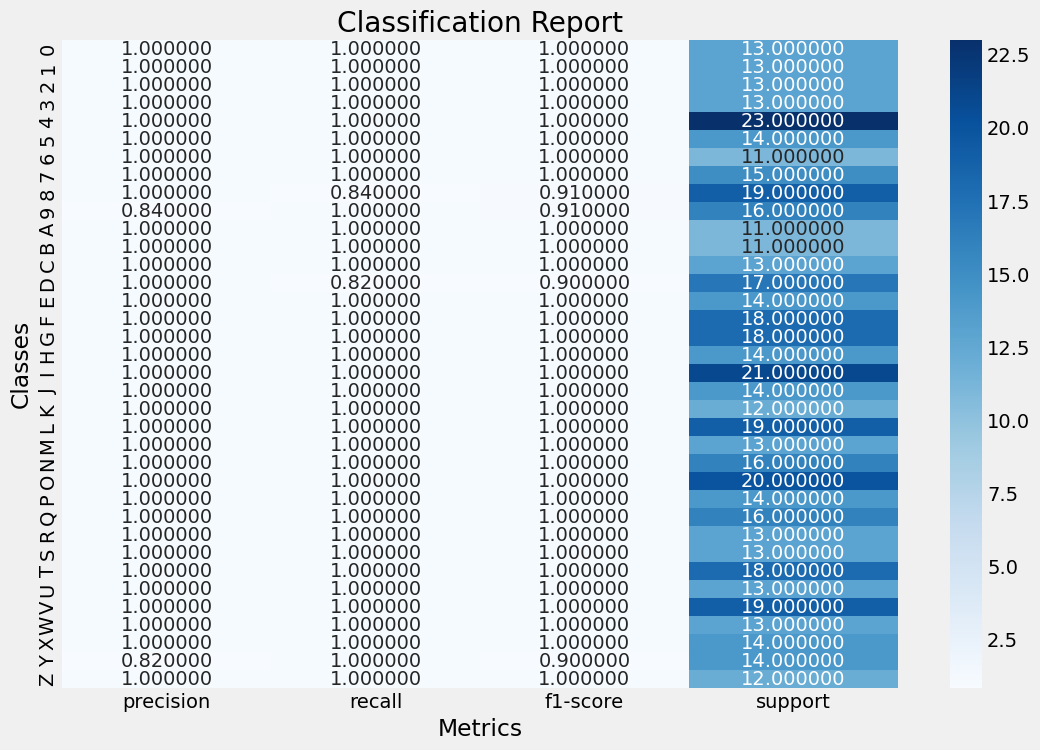

In [39]:
# Create a heatmap-style plot for classification report metrics
def plot_classification_report(report):
    report_data = []
    lines = report.split('\n')
    for line in lines[2:-5]:
        row = line.split()
        report_data.append(row)

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(np.array(report_data)[:, 1:].astype(float), annot=True, cmap='Blues', fmt='f', xticklabels=['precision', 'recall', 'f1-score', 'support'], yticklabels=classes)
    #sns.heatmap(np.array(report_data)[:, 1:].astype(float), annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=np.array(report_data)[:, 0])
    plt.xlabel("Metrics")
    plt.ylabel("Classes")
    plt.title("Classification Report")
    plt.savefig('classification.png')
    plt.show()

# Plot the classification report
plot_classification_report(report)

In [40]:
with tf.device('/GPU:0'):
    # Define callback for saving the best model weights based on validation accuracy
    model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, save_weights_only=True, monitor='val_accuracy', mode='max')
    # Define callback for early stopping based on validation accuracy
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=100, restore_best_weights=True)
    # Train your model with the callbacks
    history = tcn_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), callbacks=[model_checkpoint, early_stopping])
    # Load the best weights
    tcn_model.load_weights('best_model.h5')
    # Evaluate the model on the validation set to get the peak validation accuracy
    peak_test_loss, peak_test_accuracy = tcn_model.evaluate(X_test, y_test)

Epoch 1/500
68/68 [==============================] - 3s 49ms/step - loss: 0.0706 - accuracy: 0.9792 - val_loss: 0.0527 - val_accuracy: 0.9926
Epoch 2/500
68/68 [==============================] - 3s 47ms/step - loss: 0.0639 - accuracy: 0.9843 - val_loss: 0.0522 - val_accuracy: 0.9889
Epoch 3/500
68/68 [==============================] - 3s 50ms/step - loss: 0.0706 - accuracy: 0.9782 - val_loss: 0.0455 - val_accuracy: 0.9870
Epoch 4/500
68/68 [==============================] - 3s 45ms/step - loss: 0.0680 - accuracy: 0.9806 - val_loss: 0.0501 - val_accuracy: 0.9889
Epoch 5/500
68/68 [==============================] - 3s 46ms/step - loss: 0.0636 - accuracy: 0.9838 - val_loss: 0.0479 - val_accuracy: 0.9926
Epoch 6/500
68/68 [==============================] - 3s 46ms/step - loss: 0.0719 - accuracy: 0.9769 - val_loss: 0.0588 - val_accuracy: 0.9889
Epoch 7/500
68/68 [==============================] - 3s 45ms/step - loss: 0.0734 - accuracy: 0.9792 - val_loss: 0.0488 - val_accuracy: 0.9833
Epoch 

In [41]:
print(f"Peak Test Loss: {peak_test_loss:.4f}, Peak Test Accuracy: {peak_test_accuracy*100:.4f}%")

Peak Test Loss: 0.0527, Peak Test Accuracy: 99.2593%


In [58]:
import os
import random

def get_first_token(input_string):
    tokens = input_string.split("_")
    if tokens:
        return tokens[0]
    return None
    
def get_second_token(input_string):
    tokens = input_string.split("_")
    if tokens:
        return tokens[1]
    return None
    
# Set the directory path
directory_path = "./archive/fold16/output/"
correct1 = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        #print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                print("Prediction:", prediction_class[0])
                if(second_token == prediction_class[0]):
                    correct1 = correct1 + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    print("Prediction:", prediction_class[0])
                    if(first_token == prediction_class[0]):
                        correct1 = correct1 + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/output/augmented_A_split_20_1.wav
1/1 [==============================] - 0s 35ms/step
Second token: A
Prediction: A
1
Randomly selected file: ./archive/fold16/output/augmented_X_split_24_1.wav
1/1 [==============================] - 0s 45ms/step
Second token: X
Prediction: X
2
Randomly selected file: ./archive/fold16/output/augmented_2_split_4_2.wav
1/1 [==============================] - 0s 39ms/step
Second token: 2
Prediction: 2
3
Randomly selected file: ./archive/fold16/output/augmented_E_split_18_2.wav
1/1 [==============================] - 0s 44ms/step
Second token: E
Prediction: E
4
Randomly selected file: ./archive/fold16/output/augmented_Z_split_24_2.wav
1/1 [==============================] - 0s 37ms/step
Second token: Z
Prediction: Z
5
Randomly selected file: ./archive/fold16/output/augmented_A_split_18_2.wav
1/1 [==============================] - 0s 55ms/step
Second token: A
Prediction: A
6
Randomly selected file: ./archive/fold16/output

In [60]:
print("Guess: ", correct1,"%") 

Guess:  99 %


In [79]:
# Set the directory path
directory_path = "./archive/fold16/1secs/nord/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/nord/d_split_8.wav
1/1 [==============================] - 0s 58ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/nord/a_split_2.wav
1/1 [==============================] - 0s 48ms/step
Predicted:  u
First token: a
Randomly selected file: ./archive/fold16/1secs/nord/s_split_4.wav
1/1 [==============================] - 0s 77ms/step
Predicted:  q
First token: s
Randomly selected file: ./archive/fold16/1secs/nord/r_split_7.wav
1/1 [==============================] - 0s 64ms/step
Predicted:  q
First token: r
Randomly selected file: ./archive/fold16/1secs/nord/o_split_6.wav
1/1 [==============================] - 0s 41ms/step
Predicted:  4
First token: o
Randomly selected file: ./archive/fold16/1secs/nord/r_split_7.wav
1/1 [==============================] - 0s 42ms/step
Predicted:  q
First token: r
Randomly selected file: ./archive/fold16/1secs/nord/p_split_1.wav
1/1 [==============================] - 0s 41ms/step


In [62]:
print("Guess: ", correct,"/100") 

Guess:  16 /100


In [65]:
# Set the directory path
directory_path = "./archive/fold16/1secs/est/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/est/r_split_7.wav
1/1 [==============================] - 0s 32ms/step
Predicted:  e
First token: r
Randomly selected file: ./archive/fold16/1secs/est/s_split_4.wav
1/1 [==============================] - 0s 40ms/step
Predicted:  t
First token: s
Randomly selected file: ./archive/fold16/1secs/est/a_split_2.wav
1/1 [==============================] - 0s 36ms/step
Predicted:  5
First token: a
Randomly selected file: ./archive/fold16/1secs/est/d_split_8.wav
1/1 [==============================] - 0s 36ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/est/1_split_10.wav
1/1 [==============================] - 0s 33ms/step
Predicted:  e
First token: 1
Randomly selected file: ./archive/fold16/1secs/est/s_split_4.wav
1/1 [==============================] - 0s 31ms/step
Predicted:  t
First token: s
Randomly selected file: ./archive/fold16/1secs/est/s_split_3.wav
1/1 [==============================] - 0s 37ms/step
Predic

In [66]:
print("Guess: ", correct,"/100") 

Guess:  0 /100


In [67]:
# Set the directory path
directory_path = "./archive/fold16/1secs/ovest/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/ovest/0_split_9.wav
1/1 [==============================] - 0s 34ms/step
Predicted:  q
First token: 0
Randomly selected file: ./archive/fold16/1secs/ovest/p_split_1.wav
1/1 [==============================] - 0s 38ms/step
Predicted:  z
First token: p
Randomly selected file: ./archive/fold16/1secs/ovest/d_split_8.wav
1/1 [==============================] - 0s 36ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/ovest/d_split_8.wav
1/1 [==============================] - 0s 52ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/ovest/0_split_9.wav
1/1 [==============================] - 0s 38ms/step
Predicted:  q
First token: 0
Randomly selected file: ./archive/fold16/1secs/ovest/o_split_6.wav
1/1 [==============================] - 0s 41ms/step
Predicted:  8
First token: o
Randomly selected file: ./archive/fold16/1secs/ovest/p_split_1.wav
1/1 [==============================] - 0s 44m

In [68]:
print("Guess: ", correct,"/100") 

Guess:  0 /100


In [69]:
# Set the directory path
directory_path = "./archive/fold16/1secs/sud/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/sud/w_split_5.wav
1/1 [==============================] - 0s 41ms/step
Predicted:  e
First token: w
Randomly selected file: ./archive/fold16/1secs/sud/d_split_8.wav
1/1 [==============================] - 0s 41ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/sud/d_split_8.wav
1/1 [==============================] - 0s 35ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/sud/o_split_6.wav
1/1 [==============================] - 0s 34ms/step
Predicted:  u
First token: o
Randomly selected file: ./archive/fold16/1secs/sud/d_split_8.wav
1/1 [==============================] - 0s 43ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/sud/p_split_1.wav
1/1 [==============================] - 0s 35ms/step
Predicted:  8
First token: p
Randomly selected file: ./archive/fold16/1secs/sud/w_split_5.wav
1/1 [==============================] - 0s 37ms/step
Predict

In [70]:
print("Guess: ", correct,"/100") 

Guess:  0 /10


In [71]:
# Set the directory path
directory_path = "./archive/fold16/1secs/nordest/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/nordest/1_split_10.wav
1/1 [==============================] - 0s 38ms/step
Predicted:  t
First token: 1
Randomly selected file: ./archive/fold16/1secs/nordest/0_split_9.wav
1/1 [==============================] - 0s 38ms/step
Predicted:  8
First token: 0
Randomly selected file: ./archive/fold16/1secs/nordest/a_split_2.wav
1/1 [==============================] - 0s 37ms/step
Predicted:  8
First token: a
Randomly selected file: ./archive/fold16/1secs/nordest/s_split_4.wav
1/1 [==============================] - 0s 36ms/step
Predicted:  8
First token: s
Randomly selected file: ./archive/fold16/1secs/nordest/o_split_6.wav
1/1 [==============================] - 0s 42ms/step
Predicted:  u
First token: o
Randomly selected file: ./archive/fold16/1secs/nordest/p_split_1.wav
1/1 [==============================] - 0s 49ms/step
Predicted:  u
First token: p
Randomly selected file: ./archive/fold16/1secs/nordest/s_split_4.wav
1/1 [=========================

In [72]:
print("Guess: ", correct,"/100") 

Guess:  0 /10


In [73]:
# Set the directory path
directory_path = "./archive/fold16/1secs/nordovest/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/nordovest/r_split_7.wav
1/1 [==============================] - 0s 49ms/step
Predicted:  i
First token: r
Randomly selected file: ./archive/fold16/1secs/nordovest/a_split_2.wav
1/1 [==============================] - 0s 37ms/step
Predicted:  v
First token: a
Randomly selected file: ./archive/fold16/1secs/nordovest/s_split_4.wav
1/1 [==============================] - 0s 55ms/step
Predicted:  4
First token: s
Randomly selected file: ./archive/fold16/1secs/nordovest/d_split_8.wav
1/1 [==============================] - 0s 54ms/step
Predicted:  v
First token: d
Randomly selected file: ./archive/fold16/1secs/nordovest/0_split_9.wav
1/1 [==============================] - 0s 54ms/step
Predicted:  h
First token: 0
Randomly selected file: ./archive/fold16/1secs/nordovest/p_split_1.wav
1/1 [==============================] - 0s 65ms/step
Predicted:  2
First token: p
Randomly selected file: ./archive/fold16/1secs/nordovest/w_split_5.wav
1/1 [============

In [74]:
print("Guess: ", correct,"/100") 

Guess:  0 /100


In [75]:
# Set the directory path
directory_path = "./archive/fold16/1secs/sudest/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token.lower())
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token.lower())
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/sudest/s_split_4.wav
1/1 [==============================] - 0s 44ms/step
Predicted:  p
First token: s
Randomly selected file: ./archive/fold16/1secs/sudest/w_split_5.wav
1/1 [==============================] - 0s 45ms/step
Predicted:  t
First token: w
Randomly selected file: ./archive/fold16/1secs/sudest/s_split_4.wav
1/1 [==============================] - 0s 32ms/step
Predicted:  p
First token: s
Randomly selected file: ./archive/fold16/1secs/sudest/a_split_2.wav
1/1 [==============================] - 0s 35ms/step
Predicted:  e
First token: a
Randomly selected file: ./archive/fold16/1secs/sudest/d_split_8.wav
1/1 [==============================] - 0s 38ms/step
Predicted:  u
First token: d
Randomly selected file: ./archive/fold16/1secs/sudest/p_split_1.wav
1/1 [==============================] - 0s 36ms/step
Predicted:  o
First token: p
Randomly selected file: ./archive/fold16/1secs/sudest/p_split_1.wav
1/1 [==============================] -

In [76]:
print("Guess: ", correct,"/100") 

Guess:  0 /100


In [77]:
# Set the directory path
directory_path = "./archive/fold16/1secs/sudovest/"
correct = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,100):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token.lower())
                if(second_token.lower() == prediction_class[0].lower()):
                    correct = correct + 1
            else:
                if first_token is not None:
                    print("First token:", first_token.lower())
                    if(first_token.lower() == prediction_class[0].lower()):
                        correct = correct + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")

Randomly selected file: ./archive/fold16/1secs/sudovest/a_split_2.wav
1/1 [==============================] - 0s 37ms/step
Predicted:  u
First token: a
Randomly selected file: ./archive/fold16/1secs/sudovest/1_split_10.wav
1/1 [==============================] - 0s 35ms/step
Predicted:  e
First token: 1
Randomly selected file: ./archive/fold16/1secs/sudovest/1_split_10.wav
1/1 [==============================] - 0s 36ms/step
Predicted:  e
First token: 1
Randomly selected file: ./archive/fold16/1secs/sudovest/p_split_1.wav
1/1 [==============================] - 0s 34ms/step
Predicted:  e
First token: p
Randomly selected file: ./archive/fold16/1secs/sudovest/d_split_8.wav
1/1 [==============================] - 0s 33ms/step
Predicted:  e
First token: d
Randomly selected file: ./archive/fold16/1secs/sudovest/s_split_3.wav
1/1 [==============================] - 0s 34ms/step
Predicted:  t
First token: s
Randomly selected file: ./archive/fold16/1secs/sudovest/d_split_8.wav
1/1 [=================

In [78]:
print("Guess: ", correct,"/100") 

Guess:  0 /100
